# Reward overview — latest (two-blob) reward

Plots the reward landscape actually used in `UnbalancedDiskDiscrete_new_reward.py`:

- **goal** gaussian at the top (±180°, ω=0)
- **bottom penalty** (wide) around 0°
- **sharp precision peak** at the top
- the **two-blob `Z`** that encodes the energy-pumping swing-up path: high |ω| far from the top, decaying to ω≈0 at the top — symmetric for the **left and right** swing-up.

Axes match the agent's observation: **angle ±225° (5π/4)** and **ω ±30 rad/s**, so the crest (peaking at ~±27 rad/s near the bottom) now sits fully inside what the agent can perceive.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Reward used in UnbalancedDiskDiscrete_new_reward.py (vectorized voor plotten).
# th = hoek (0 = onder, +-pi = boven), omega = hoeksnelheid.

def err(c, t):                      # minimale hoekfout (wrap-aware), == self.err
    return np.abs(((c - t + np.pi) % (2 * np.pi)) - np.pi)

def g2d(vx, vy, sx, sy, scale):     # 2D gaussian met rho=0
    return scale * (1.0 / (2 * np.pi * sx * sy)) * np.exp(-0.5 * ((vx / sx) ** 2 + (vy / sy) ** 2))

def calculate_z(x, y):              # twee-blob S-curve: codeert de swing-up baan
    l, p, g, f, c, w, d = 3, np.pi, 2.55, -0.95, 4.57, 29.5, 1.91
    b1 = f * (-x + p); pt1 = np.sign(b1) * np.abs(b1) ** l
    s1 = 3 * np.exp(-((y + pt1) ** 2) / (c + w * (-x + p) ** 2))
    e1 = g / (d * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((-x + p) / d) ** 2)
    b2 = f * (-x - p); pt2 = np.sign(b2) * np.abs(b2) ** l
    s2 = 3 * np.exp(-((y + pt2) ** 2) / (c + w * (-x - p) ** 2))
    e2 = g / (d * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((-x - p) / d) ** 2)
    return np.maximum(s1 * e1, s2 * e2)   # links + rechts symmetrisch

def reward(th, omega, u=0.0):
    return (g2d(err(th, np.pi), omega, 1, 1, 2)        # doel: top, omega 0
            - g2d(err(th, 0),    omega, 3, 3, 40)      # straf: onderin
            + g2d(err(th, np.pi), omega, 0.15, 0.15, 0.05)  # scherpe piek bovenin
            - 0.001 * u ** 2                            # control penalty
            + calculate_z(th, omega))                  # swing-up crest

def crest1(th): b = -0.95 * (-th + np.pi); return -np.sign(b) * np.abs(b) ** 3  # rechter swing-up
def crest2(th): b = -0.95 * (-th - np.pi); return -np.sign(b) * np.abs(b) ** 3  # linker swing-up

TH_MAX = 5 * np.pi / 4   # +-225 graden  (== observatie-/terminatie-grens)
OM_MAX = 30.0            # +-30 rad/s    (== observatie-grens)
th = np.linspace(-TH_MAX, TH_MAX, 400)
om = np.linspace(-OM_MAX, OM_MAX, 400)
TH, OM = np.meshgrid(th, om)
R = reward(TH, OM)
print("grid klaar:", R.shape, " reward range [%.2f, %.2f]" % (R.min(), R.max()))


grid klaar: (400, 400)  reward range [-0.67, 1.82]


### 3D landscape (three viewpoints)

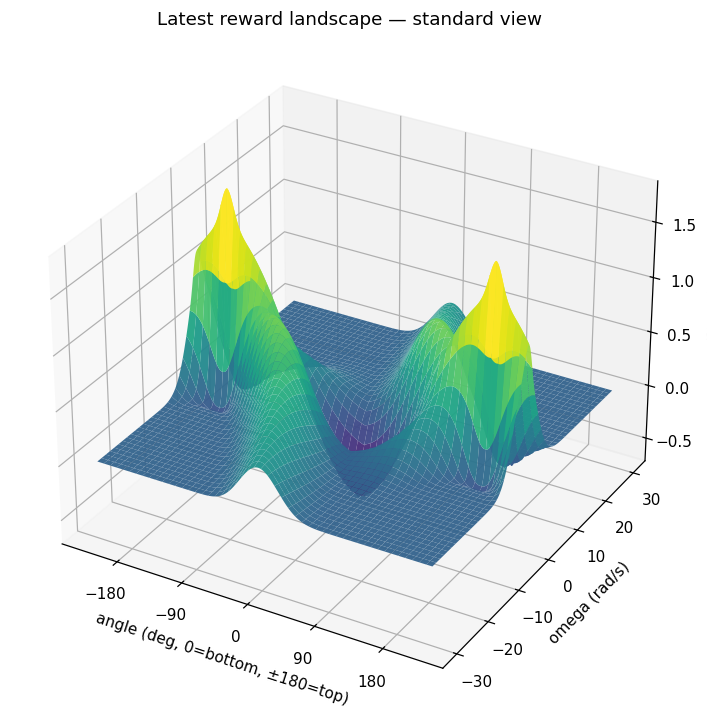

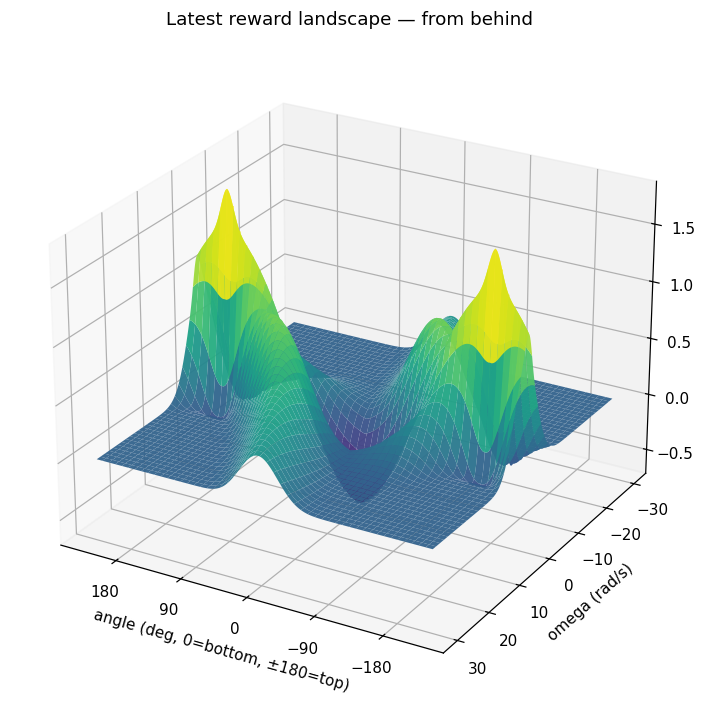

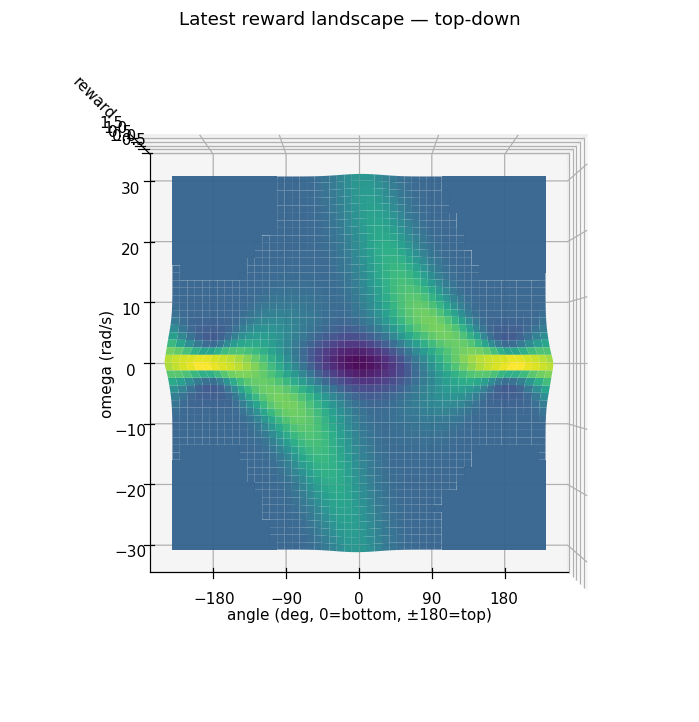

In [ ]:
for elev, azim, suffix in [(30, -60, "standard view"), (25, 120, "from behind"), (90, -90, "top-down")]:
    fig = plt.figure(figsize=(11, 8)); ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(np.degrees(TH), OM, R, cmap="viridis", edgecolor="none", alpha=0.95)
    ax.set_xlabel("angle (deg, 0=bottom, ±180=top)"); ax.set_ylabel("omega (rad/s)"); ax.set_zlabel("reward")
    ax.set_title(f"Latest reward landscape — {suffix}")
    ax.set_xticks([-180, -90, 0, 90, 180]); ax.view_init(elev=elev, azim=azim)
    plt.show()


### Top-down: the swing-up crest vs the observable band
Red = the ideal speed-vs-angle path. White solid = current ω bound (±30); white dotted = the old ±5 bound that made the energetic part of the swing invisible.

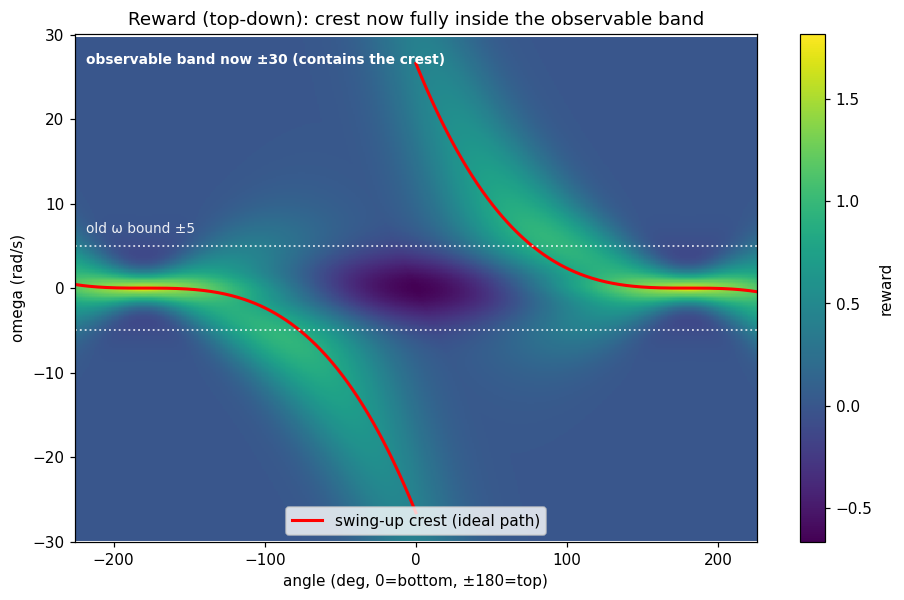

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
pc = ax.pcolormesh(np.degrees(TH), OM, R, cmap="viridis", shading="auto")
fig.colorbar(pc, label="reward")
thr = np.linspace(0, TH_MAX, 200); thl = np.linspace(-TH_MAX, 0, 200)
ax.plot(np.degrees(thr), crest1(thr), "r-", lw=2, label="swing-up crest (ideal path)")
ax.plot(np.degrees(thl), crest2(thl), "r-", lw=2)
for s in (OM_MAX, -OM_MAX): ax.axhline(s, color="w", ls="-", lw=2)
for s in (5, -5):           ax.axhline(s, color="w", ls=":", lw=1.2, alpha=0.8)
ax.text(-218, 6.5, "old ω bound ±5", color="w", fontsize=9, alpha=0.9)
ax.text(-218, 26.5, "observable band now ±30 (contains the crest)", color="w", fontsize=9, weight="bold")
ax.set_xlabel("angle (deg, 0=bottom, ±180=top)"); ax.set_ylabel("omega (rad/s)")
ax.set_title("Reward (top-down): crest now fully inside the observable band")
ax.legend(loc="lower center"); plt.show()


### Verify the plot equals the trained env's reward

In [ ]:
# Sanity-check: plot-reward == env-reward (zelfde formule, andere code-pad).
from UnbalancedDiskDiscrete_new_reward import UnbalancedDisk
_env = UnbalancedDisk(dt=0.025); _env.u = 0.0
_maxerr = 0.0
for _th in np.linspace(-TH_MAX, TH_MAX, 40):
    for _w in np.linspace(-OM_MAX, OM_MAX, 40):
        _env.th, _env.omega = _th, _w
        _maxerr = max(_maxerr, abs(float(_env.reward_fun(_env)) - float(reward(_th, _w))))
print("max |plot - env| = %.2e" % _maxerr)
assert _maxerr < 1e-9, "plot wijkt af van de env-reward!"
print("OK: de plot komt exact overeen met de reward in de getrainde omgeving.")


max |plot - env| = 4.44e-16
OK: de plot komt exact overeen met de reward in de getrainde omgeving.
